In [1]:
import os
import sys
import random
import optuna
import numpy as np
import pandas as pd
from dotenv import load_dotenv

sys.path.append("..")
from feature_engineering import time_based_train_test_split, get_return, round_to_step, get_mask, add_week_column, objective, get_best_features, get_feature_bins_map
from etl_pipeline_local import get_under_25_table

sys.path.append("../..")
from strategies.strategies_utils import analyze_strategies, get_best_strategies

from utils import trial_key, run_one_study
pd.set_option('display.max_columns', None)
optuna.logging.set_verbosity(optuna.logging.WARN)

load_dotenv()

True

In [2]:
# TODO: aggiungere early stopping

# 1. Load Data

In [3]:
# Bet setup
target_col = "under_25"
odds_col: str = "underOver_quote_currentU"

# Load data
df_loaded = get_under_25_table()
df_loaded = df_loaded.sort_values('time').reset_index(drop=True)
df = df_loaded.copy()

# Feature Engineering
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x[odds_col]), axis=1).copy()
df["week"] = add_week_column(df)
df = df[df["underOver_quote_currentU"] >= 1.3]

# Train/test split
df_train, df_test = time_based_train_test_split(df=df, time_col="time", train_frac=0.8)

# Feature acquisition
chance_features = list(df.filter(like="chance").columns)
goalNoGoal_features = list(df.filter(like="goalNoGoal").columns)
underOver_features = list(df.filter(like="underOver").columns)
evaluation_features = list(df.filter(like="evaluation").columns)
features_tot = chance_features + goalNoGoal_features + underOver_features + evaluation_features # goalNoGoal_features + underOver_features + evaluation_features

# 2. Feature Selection

In [4]:
# Define the feature selection raw search
objective_hyperparameters = {
    "n_trials": 500, # 500 - 1000
    "n_studies": 5, # 50
    "min_obs": 100, 
    "lambda": 1, # 0.5, 1, 2
    "tpe_sampler": 
        {
            "n_startup_trials": 10, # 100, # 10 - 30 per search space semplici, 50 100+ per seearch space con molti minimi
            "n_ei_candidates": 24, #128 # 24 default, problemi difficili: 64 o 128
        }
}

feature_rank = get_best_features(df=df_train, features=features_tot, objective_hyperparameters=objective_hyperparameters)

In [16]:
# Retrieve feature_bins_map draft
threshold = feature_rank['score'].quantile(0.9)
top_features = feature_rank[feature_rank['score'] >= threshold]['feature'].tolist()
feature_bins_map = get_feature_bins_map(df_train, top_features)
feature_bins_map

{'underOver_quote_diffRealCurrO': 5,
 'underOver_quote_currentO': 0.2,
 'underOver_quote_initialO': 0.2,
 'underOver_quote_diffInitialCurrU': 5,
 'chance1x2_quote_diffRealCurr2': 5,
 'chance1x2_quote_diffInitialCurr1': 5,
 'underOver_bookkeeping_u': 5,
 'underOver_bookkeeping_o': 5,
 'chance1x2_quote_diffRealCurrx': 5,
 'underOver_quote_diffInitialCurrO': 5,
 'underOver_chance_under05HT': 5,
 'underOver_chance_over05HT': 5,
 'chance1x2_chance_p12': 5,
 'goalNoGoal_quote_currentNG': 0.2}

In [6]:
feature_rank.head(30)

,feature,score
0,underOver_quote_diffRealCurrO,-1.114676
1,underOver_quote_currentO,-1.277523
2,underOver_quote_initialO,-1.299776
3,underOver_quote_diffInitialCurrU,-1.311164
4,chance1x2_quote_diffRealCurr2,-1.514635
5,chance1x2_quote_diffInitialCurr1,-1.535381
6,underOver_bookkeeping_u,-1.550195
7,underOver_bookkeeping_o,-1.550195
8,chance1x2_quote_diffRealCurrx,-1.618091
9,underOver_quote_diffInitialCurrO,-1.621246


## 2. Define Parameters

In [37]:
# Define features and relative step

feature_bins_map = {
    'underOver_quote_diffRealCurrO': 5,
    # 'underOver_quote_currentO': 0.2,
    # 'underOver_quote_initialO': 0.2,
    'underOver_quote_diffInitialCurrU': 5,
    # 'chance1x2_quote_diffRealCurr2': 5,
    # 'chance1x2_quote_diffInitialCurr1': 5,
    'underOver_bookkeeping_u': 5,
    # 'chance1x2_quote_diffRealCurrx': 5,
    'underOver_quote_diffInitialCurrO': 5,
    'underOver_chance_under05HT': 5,
    # 'chance1x2_chance_p12': 5,
    'goalNoGoal_quote_currentNG': 0.2
 }
 

objective_hyperparameters = {
    "n_trials": 500, # 500 - 1000
    "n_studies": 50, # 50
    "min_obs": 100, 
    "lambda": 1, # 0.5, 1, 2
    "tpe_sampler": 
    {
        "n_startup_trials": 100, # 10 - 30 per search space semplici, 50 100+ per seearch space con molti minimi
        "n_ei_candidates": 128 # 24 default, problemi difficili: 64 o 128
    }
}

# Create the binned dataframe
df_train_binned = df_train.copy()

for feat, step in feature_bins_map.items():
    df_train_binned[feat] = [round_to_step(x, step) for x in df_train_binned[feat]]

    if isinstance(step, int):
        df_train_binned[feat] = df_train_binned[feat].astype("Int64")

print("SEARCH SPACE\n")
for feat in feature_bins_map.keys():
    space = df_train_binned[feat].sort_values(ascending=True).unique()
    print(f"Feature: {feat}")
    print(f"Search space: {space}")
    print("\n")

SEARCH SPACE

Feature: underOver_quote_diffRealCurrO
Search space: <IntegerArray>
[-55, -45, -40, -35, -30, -25, -20, -15, -10,  -5,   0,   5,  10,  15,  20,
  25,  30,  35,  40,  45,  50,  55,  60,  65,  70,  75,  80,  85,  90,  95,
 100, 105, 110, 115, 120, 130, 135, 140, 145, 150, 155, 160, 165, 175, 185,
 195, 200, 345]
Length: 48, dtype: Int64


Feature: underOver_quote_diffInitialCurrU
Search space: <IntegerArray>
[-35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35, 40]
Length: 16, dtype: Int64


Feature: underOver_bookkeeping_u
Search space: <IntegerArray>
[15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75]
Length: 13, dtype: Int64


Feature: underOver_quote_diffInitialCurrO
Search space: <IntegerArray>
[-35, -30, -25, -20, -15, -10, -5, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45]
Length: 17, dtype: Int64


Feature: underOver_chance_under05HT
Search space: <IntegerArray>
[10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
Length: 13, dtype: Int64


Feature: goalNoGoal_qu

## 3. Optimize

In [38]:
optuna.logging.set_verbosity(optuna.logging.WARN)

# Generate random seeds
seeds = [random.randint(0, 2**32 - 1) for _ in range(objective_hyperparameters["n_studies"])]
studies = [
    run_one_study(
        seed=s, 
        objective_hyperparameters=objective_hyperparameters, 
        objective=objective,
        feature_bins_map=feature_bins_map, 
        df_binned=df_train_binned
        ) 
        for s in seeds]

all_trials = []
for study in studies:
    all_trials.extend(
        [t for t in study.trials if t.value is not None and t.state.name == "COMPLETE"]
    )

top_trials = sorted(all_trials, key=lambda t: -t.value)
best_trials = top_trials[:10]
print(best_trials)

/home/maicolnicolini/code/bet-master-analytics/src/models/under_25/../feature_engineering.py:321: UserWarning: The distribution is specified by [1.2000000000000002, 3.6] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 3.4000000000000004].
  feat_min = trial.suggest_float(
/home/maicolnicolini/code/bet-master-analytics/src/models/under_25/../feature_engineering.py:327: UserWarning: The distribution is specified by [1.2000000000000002, 3.8000000000000003] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 3.8000000000000003].
  feat_max = trial.suggest_float(
/home/maicolnicolini/code/bet-master-analytics/src/models/under_25/../feature_engineering.py:321: UserWarning: The distribution is specified by [1.2000000000000002, 3.6] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 3.4000000000000004].
  feat_min = trial.suggest_float(
/hom

[FrozenTrial(number=233, state=<TrialState.COMPLETE: 1>, values=[-1.3111641863640289], datetime_start=datetime.datetime(2026, 4, 15, 9, 22, 33, 847762), datetime_complete=datetime.datetime(2026, 4, 15, 9, 22, 33, 876874), params={'underOver_quote_diffRealCurrO_use_min': True, 'underOver_quote_diffRealCurrO_use_max': False, 'use_underOver_quote_diffRealCurrO': False, 'underOver_quote_diffRealCurrO_min': 235, 'underOver_quote_diffRealCurrO_max': 335, 'underOver_quote_diffInitialCurrU_use_min': True, 'underOver_quote_diffInitialCurrU_use_max': True, 'use_underOver_quote_diffInitialCurrU': True, 'underOver_quote_diffInitialCurrU_min': 20, 'underOver_quote_diffInitialCurrU_max': 25, 'underOver_bookkeeping_u_use_min': False, 'underOver_bookkeeping_u_use_max': True, 'use_underOver_bookkeeping_u': False, 'underOver_bookkeeping_u_min': 55, 'underOver_bookkeeping_u_max': 65, 'underOver_quote_diffInitialCurrO_use_min': False, 'underOver_quote_diffInitialCurrO_use_max': True, 'use_underOver_quote_

## 4. Evaluate

In [39]:
# Create the test binned dataframe
return_threshold = -3.
df_test_binned = df_test.copy()

for feat, step in feature_bins_map.items():
    df_test_binned[feat] = [round_to_step(x, step) for x in df_test_binned[feat]]

    if isinstance(step, int):
        df_test_binned[feat] = df_test_binned[feat].astype("Int64")

# Get the resulting dataframes
for i, trial in enumerate(best_trials):
    params_dict = best_trials[i].user_attrs["params_dict"]

    train_mask = get_mask(df_train_binned, params_dict)
    test_mask = get_mask(df_test_binned, params_dict)

    df_train_filtered = df_train_binned[train_mask]
    df_test_filtered = df_test_binned[test_mask]

    df = pd.concat([df_train_filtered, df_test_filtered], axis=0)
    min_return = df.groupby('week')['return'].sum().min()
    max_return = df.groupby('week')['return'].sum().max()

    if min_return >= return_threshold:
        print(f"Trial no. {i}")
        print(f"Min return {min_return}")
        print(f"Max return {max_return}")
        print(f"Score {trial.value}")
        print("\n")

Trial no. 0
Min return -2.93
Max return 2.09
Score -1.3111641863640289


Trial no. 1
Min return -2.93
Max return 2.09
Score -1.3111641863640289


Trial no. 2
Min return -2.93
Max return 2.09
Score -1.3111641863640289


Trial no. 3
Min return -2.93
Max return 2.09
Score -1.3111641863640289


Trial no. 4
Min return -2.93
Max return 2.09
Score -1.3111641863640289


Trial no. 5
Min return -2.93
Max return 2.09
Score -1.3111641863640289


Trial no. 6
Min return -2.93
Max return 2.09
Score -1.3111641863640289


Trial no. 7
Min return -2.93
Max return 2.09
Score -1.3111641863640289


Trial no. 8
Min return -2.93
Max return 2.09
Score -1.3111641863640289


Trial no. 9
Min return -2.93
Max return 2.09
Score -1.3111641863640289




Mean Train ROI: -0.038702290076335875
Train Accuracy: 0.5 (68/131)
Mean Test ROI: -0.3409999999999999
Test Accuracy: 0.3 (3/10)


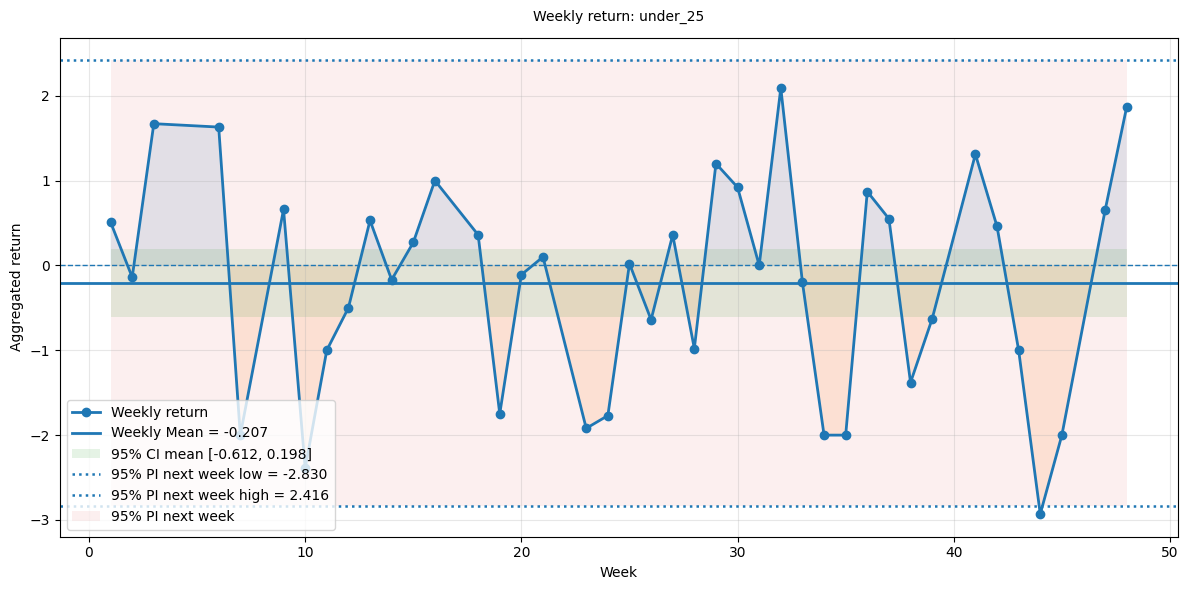

In [40]:
best_score_idx = 0

params_dict = best_trials[best_score_idx].user_attrs["params_dict"]

train_mask = get_mask(df_train_binned, params_dict)
test_mask = get_mask(df_test_binned, params_dict)

df_train_filtered = df_train_binned[train_mask]
df_test_filtered = df_test_binned[test_mask]


mean_roi = df_train_filtered["return"].mean()
right = df_train_filtered[target_col].sum()  
total = df_train_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean Train ROI: {mean_roi}")
print(f"Train Accuracy: {accuracy} ({right}/{total})")


mean_roi = df_test_filtered["return"].mean()
right = df_test_filtered[target_col].sum()  
total = df_test_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean Test ROI: {mean_roi}")
print(f"Test Accuracy: {accuracy} ({right}/{total})")


df_tot_filtered = pd.concat([df_train_filtered, df_test_filtered], axis=0).reset_index(drop=True).rename(columns={target_col: "result", "time": "date"})
df_tot_filtered = df_tot_filtered.sort_values(by="date", ascending=False)
 
df_tot_filtered["strategy"] = target_col

weekly_return, stats = analyze_strategies(df_tot_filtered, strategies=[target_col], print_pi=True)

In [73]:
# Get Stats
weeks = stats["n_weeks"]
total_weeks = max(df["week"])

print(f"No. of weeks covered: {weeks}/{total_weeks} ({np.round((weeks/total_weeks), 2)})")
weekly_stats = get_best_strategies(df_tot_filtered).iloc[0].to_dict()
weekly_stats["weeks_covered"] = np.round((weeks/total_weeks), 2)

get_best_strategies(df_tot_filtered)

No. of weeks covered: 34/49 (0.69)


,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
over_15,0.73,0.97,2.84,2.93,139,0.84


## 5. Save best Trials

In [74]:
# Save best trials 
trial_to_save = best_trials[best_score_idx]

trial_to_save.set_user_attr("feature_bins_map", feature_bins_map)
trial_to_save.set_user_attr("weekly_stats", weekly_stats) 

study = optuna.create_study(
    study_name=f"{target_col}_aggregated_study",
    storage=os.getenv("OPTUNA_STORAGE"),
    direction="maximize",   
    load_if_exists=True,
)

existing = {trial_key(t) for t in study.trials if t.value is not None}

# esempio: best_frozen_trials = [study_seed_1.best_trial, study_seed_2.best_trial, ...]
new_best_trials = [
    t for t in [trial_to_save]
    if trial_key(t) not in existing
]

if new_best_trials:
    study.add_trials(new_best_trials)

print("Aggiunti:", len(new_best_trials))
print("Totale trial archiviati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

Aggiunti: 1
Totale trial archiviati: 3
Best assoluto: -0.13275429337616318 {'underOver_quote_diffRealCurrU_use_min': False, 'underOver_quote_diffRealCurrU_use_max': True, 'use_underOver_quote_diffRealCurrU': False, 'underOver_quote_diffRealCurrU_min': 85, 'underOver_quote_diffRealCurrU_max': 300, 'goalNoGoal_stats_avgGoalTakenAway_use_min': True, 'goalNoGoal_stats_avgGoalTakenAway_use_max': False, 'use_goalNoGoal_stats_avgGoalTakenAway': True, 'goalNoGoal_stats_avgGoalTakenAway_min': 1.4000000000000001, 'goalNoGoal_stats_avgGoalTakenAway_max': 4.2, 'goalNoGoal_flashback_m24_include_missing': False, 'goalNoGoal_flashback_m24_use_min': True, 'goalNoGoal_flashback_m24_use_max': True, 'use_goalNoGoal_flashback_m24': True, 'goalNoGoal_flashback_m24_min': 62, 'goalNoGoal_flashback_m24_max': 63, 'underOver_chance_over25_use_min': False, 'underOver_chance_over25_use_max': True, 'use_underOver_chance_over25': True, 'underOver_chance_over25_min': 25, 'underOver_chance_over25_max': 60, 'underOver

/tmp/ipykernel_60717/4034433927.py:14: UserWarning: The distribution is specified by [1.2000000000000002, 6.2] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 6.0].
  existing = {trial_key(t) for t in study.trials if t.value is not None}
/tmp/ipykernel_60717/4034433927.py:14: UserWarning: The distribution is specified by [1.2000000000000002, 6.6000000000000005] and step=0.2, but the range is not divisible by `step`. It will be replaced with [1.2000000000000002, 6.6000000000000005].
  existing = {trial_key(t) for t in study.trials if t.value is not None}
